# 18. Selective Prediction and Confidence Strategy

## Objective
Transform model predictions into a realistic decision layer that prioritizes decision quality over raw prediction volume.

Decision policy:
- `Probability > 0.55` -> `BUY`
- `Probability < 0.45` -> `SELL`
- otherwise -> `NO TRADE`

This notebook preserves time-series integrity and avoids leakage.

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 250)
pd.set_option('display.width', 220)

UPPER_THRESHOLD = 0.55
LOWER_THRESHOLD = 0.45

logger = logging.getLogger('selective_decision')
if not logger.handlers:
    h = logging.StreamHandler()
    h.setFormatter(logging.Formatter('[%(levelname)s] %(message)s'))
    logger.addHandler(h)
logger.setLevel(logging.INFO)

## 1) Load Final Predictions Dataset

In [2]:
def resolve_project_root() -> Path:
    cwd = Path.cwd()
    for c in [cwd, cwd.parent, cwd.parent.parent]:
        if (c / 'ml_pipeline').exists() and (c / 'CLAUDE.md').exists():
            return c
    raise FileNotFoundError('Unable to resolve project root with ml_pipeline and CLAUDE.md')


def resolve_paths(root: Path) -> Dict[str, Path]:
    base = root / 'ml_pipeline'
    return {
        'final_predictions': base / 'Market_Data' / 'final' / 'final_predictions.parquet',
        'processed_dataset': base / 'Market_Data' / 'processed' / 'final_model_dataset_with_volatility.parquet',
        'decision_output': base / 'Market_Data' / 'final' / 'final_decision_dataset.parquet',
    }


ROOT = resolve_project_root()
PATHS = resolve_paths(ROOT)

assert PATHS['final_predictions'].exists(), f"Missing file: {PATHS['final_predictions']}"
assert PATHS['processed_dataset'].exists(), f"Missing file: {PATHS['processed_dataset']}"

pred_df = pd.read_parquet(PATHS['final_predictions']).copy()
pred_df['Date'] = pd.to_datetime(pred_df['Date'])

required_cols = {'Ticker', 'Date', 'Regime', 'Prediction', 'Probability', 'Confidence', 'Model Used'}
assert required_cols.issubset(pred_df.columns), f"final_predictions missing required columns: {required_cols - set(pred_df.columns)}"

logger.info('Loaded final predictions shape: %s', pred_df.shape)
display(pred_df.head())

[INFO] Loaded final predictions shape: (21888, 7)


,Ticker,Date,Regime,Prediction,Probability,Confidence,Model Used
0,ABB,2025-01-29,HIGH,UNCERTAIN,0.494498,Low,Transformer
1,ABB,2025-01-30,HIGH,UNCERTAIN,0.502987,Low,Transformer
2,ABB,2025-01-31,HIGH,UNCERTAIN,0.492936,Low,Transformer
3,ABB,2025-02-01,HIGH,UNCERTAIN,0.506073,Low,Transformer
4,ABB,2025-02-03,HIGH,UNCERTAIN,0.496291,Low,Transformer


## 2) Add Ground-Truth Labels for Evaluation

In [3]:
full_df = pd.read_parquet(PATHS['processed_dataset'], columns=['Ticker', 'Date', 'target', 'volatility_regime_label']).copy()
full_df['Date'] = pd.to_datetime(full_df['Date'])

eval_df = pred_df.merge(
    full_df.rename(columns={'volatility_regime_label': 'Regime_source'})[['Ticker', 'Date', 'target', 'Regime_source']],
    on=['Ticker', 'Date'],
    how='left',
)

assert eval_df['target'].isna().sum() == 0, 'Could not align targets to final predictions.'
assert (eval_df['Regime'].astype(str).str.upper() == eval_df['Regime_source'].astype(str).str.upper()).mean() > 0.99, 'Regime mismatch detected.'

eval_df['target'] = eval_df['target'].astype(int)
eval_df.drop(columns=['Regime_source'], inplace=True)
display(eval_df.head())

,Ticker,Date,Regime,Prediction,Probability,Confidence,Model Used,target
0,ABB,2025-01-29,HIGH,UNCERTAIN,0.494498,Low,Transformer,0
1,ABB,2025-01-30,HIGH,UNCERTAIN,0.502987,Low,Transformer,1
2,ABB,2025-01-31,HIGH,UNCERTAIN,0.492936,Low,Transformer,0
3,ABB,2025-02-01,HIGH,UNCERTAIN,0.506073,Low,Transformer,0
4,ABB,2025-02-03,HIGH,UNCERTAIN,0.496291,Low,Transformer,1


## 3) Decision Logic (Upper=0.55, Lower=0.45)

In [4]:
def apply_decision_logic(df_in: pd.DataFrame, lower: float, upper: float) -> pd.DataFrame:
    assert 0.0 <= lower < upper <= 1.0

    out = df_in.copy()
    out['Decision'] = np.where(
        out['Probability'] > upper,
        'BUY',
        np.where(out['Probability'] < lower, 'SELL', 'NO TRADE'),
    )
    out['Selected'] = out['Decision'] != 'NO TRADE'
    out['Decision_Pred'] = np.where(out['Decision'] == 'BUY', 1, np.where(out['Decision'] == 'SELL', 0, np.nan))
    return out


decision_df = apply_decision_logic(eval_df, lower=LOWER_THRESHOLD, upper=UPPER_THRESHOLD)
display(decision_df[['Ticker', 'Date', 'Regime', 'Probability', 'Decision', 'Selected']].head(12))

,Ticker,Date,Regime,Probability,Decision,Selected
0,ABB,2025-01-29,HIGH,0.494498,NO TRADE,False
1,ABB,2025-01-30,HIGH,0.502987,NO TRADE,False
2,ABB,2025-01-31,HIGH,0.492936,NO TRADE,False
3,ABB,2025-02-01,HIGH,0.506073,NO TRADE,False
4,ABB,2025-02-03,HIGH,0.496291,NO TRADE,False
5,ABB,2025-02-04,HIGH,0.490754,NO TRADE,False
6,ABB,2025-02-05,HIGH,0.494325,NO TRADE,False
7,ABB,2025-02-06,HIGH,0.499879,NO TRADE,False
8,ABB,2025-02-07,HIGH,0.497488,NO TRADE,False
9,ABB,2025-02-10,HIGH,0.502407,NO TRADE,False


## 4) Coverage and Selected-Set Quality Metrics

In [5]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return {
        'Accuracy': float(accuracy_score(y_true, y_pred)),
        'Precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'Recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'F1': float(f1_score(y_true, y_pred, zero_division=0)),
    }


selected_df = decision_df[decision_df['Selected']].copy()

coverage = float(len(selected_df) / len(decision_df))
selected_metrics = compute_metrics(
    y_true=selected_df['target'].astype(int).to_numpy(),
    y_pred=selected_df['Decision_Pred'].astype(int).to_numpy(),
)

summary_df = pd.DataFrame([
    {
        'Setting': 'Filtered (BUY/SELL only)',
        'Coverage': coverage,
        **selected_metrics,
    }
])
display(summary_df.round(4))
print(f"Coverage: {coverage:.2%}")

,Setting,Coverage,Accuracy,Precision,Recall,F1
0,Filtered (BUY/SELL only),0.3584,0.5093,0.512,0.4551,0.4819


Coverage: 35.84%


## 5) Curves: Coverage vs Accuracy and Threshold vs F1

,threshold,Coverage,Accuracy,Precision,Recall,F1
0,0.51,0.7222,0.5031,0.5050,0.4729,0.4884
1,0.52,0.5911,0.5051,0.5097,0.4616,0.4844
2,0.53,0.4953,0.5049,0.5083,0.4566,0.4811
3,0.54,0.4213,0.5074,0.5103,0.4554,0.4813
4,0.55,0.3584,0.5093,0.5120,0.4551,0.4819
5,0.56,0.3076,0.5106,0.5129,0.4497,0.4792
6,0.57,0.2661,0.5120,0.5102,0.4424,0.4739
7,0.58,0.2305,0.5147,0.5077,0.4363,0.4693
8,0.59,0.2002,0.5168,0.5058,0.4296,0.4646
9,0.60,0.1738,0.5251,0.5154,0.4318,0.4699


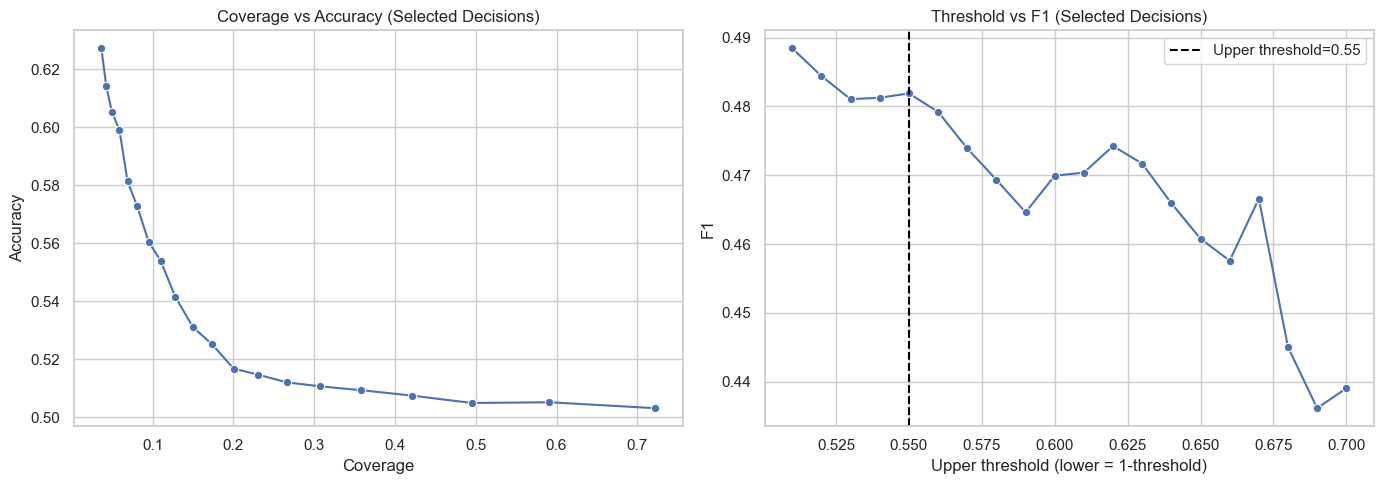

In [6]:
def evaluate_symmetric_thresholds(df_in: pd.DataFrame, thresholds: np.ndarray) -> pd.DataFrame:
    rows = []
    for t in thresholds:
        lower = 1.0 - t
        upper = t
        if lower >= upper:
            continue

        tmp = apply_decision_logic(df_in, lower=lower, upper=upper)
        sel = tmp[tmp['Selected']]
        if len(sel) == 0:
            rows.append({'threshold': float(t), 'Coverage': 0.0, 'Accuracy': np.nan, 'Precision': np.nan, 'Recall': np.nan, 'F1': np.nan})
            continue

        m = compute_metrics(sel['target'].astype(int).to_numpy(), sel['Decision_Pred'].astype(int).to_numpy())
        rows.append({'threshold': float(t), 'Coverage': len(sel) / len(tmp), **m})
    return pd.DataFrame(rows)


threshold_grid = np.round(np.arange(0.50, 0.71, 0.01), 2)
curve_df = evaluate_symmetric_thresholds(decision_df, threshold_grid)
display(curve_df.head(10).round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=curve_df, x='Coverage', y='Accuracy', marker='o', ax=axes[0])
axes[0].set_title('Coverage vs Accuracy (Selected Decisions)')
axes[0].set_xlabel('Coverage')
axes[0].set_ylabel('Accuracy')

sns.lineplot(data=curve_df, x='threshold', y='F1', marker='o', ax=axes[1])
axes[1].axvline(UPPER_THRESHOLD, color='black', linestyle='--', label=f'Upper threshold={UPPER_THRESHOLD:.2f}')
axes[1].set_title('Threshold vs F1 (Selected Decisions)')
axes[1].set_xlabel('Upper threshold (lower = 1-threshold)')
axes[1].set_ylabel('F1')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6) Regime Analysis (Filtered Decisions)

,Regime,Samples_Selected,Coverage_within_regime,Accuracy,Precision,Recall,F1
0,HIGH,36,0.0069,0.5278,0.5000,0.4118,0.4516
1,LOW,7016,0.6168,0.4999,0.4947,0.4535,0.4732
2,MEDIUM,792,0.1491,0.5922,0.6993,0.4694,0.5617


C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_21260\3448759471.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=regime_perf_df, x='Regime', y='F1', palette='viridis')


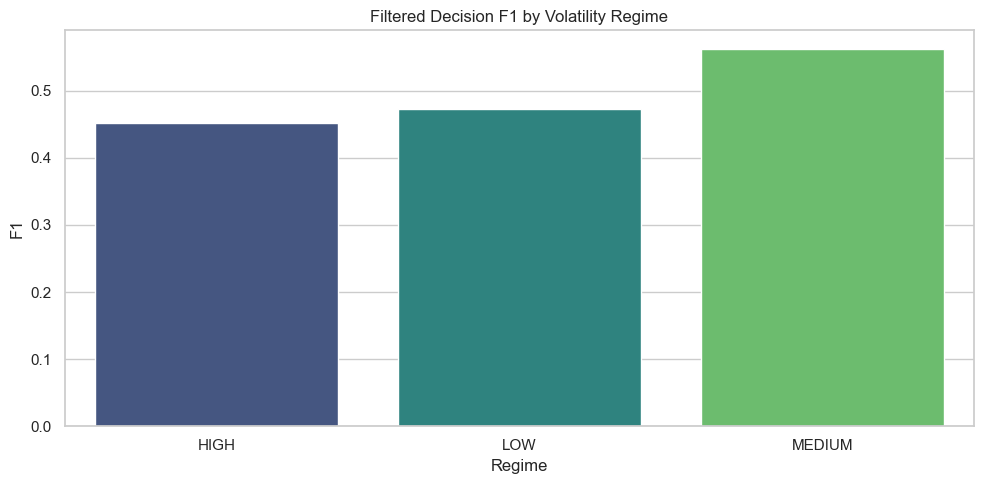

In [7]:
regime_rows = []
for regime, grp in selected_df.groupby('Regime'):
    metrics = compute_metrics(grp['target'].astype(int).to_numpy(), grp['Decision_Pred'].astype(int).to_numpy())
    regime_rows.append({
        'Regime': regime,
        'Samples_Selected': int(len(grp)),
        'Coverage_within_regime': float(len(grp) / len(decision_df[decision_df['Regime'] == regime])),
        **metrics,
    })

regime_perf_df = pd.DataFrame(regime_rows).sort_values('Regime').reset_index(drop=True)
display(regime_perf_df.round(4))

plt.figure(figsize=(10, 5))
sns.barplot(data=regime_perf_df, x='Regime', y='F1', palette='viridis')
plt.title('Filtered Decision F1 by Volatility Regime')
plt.tight_layout()
plt.show()

## 7) Compare Full Predictions vs Filtered Predictions

In [8]:
# Full predictions baseline: binary classification with probability >= 0.5
full_pred = (decision_df['Probability'] >= 0.5).astype(int)
full_metrics = compute_metrics(
    decision_df['target'].astype(int).to_numpy(),
    full_pred.to_numpy(),
)

filtered_metrics = compute_metrics(
    selected_df['target'].astype(int).to_numpy(),
    selected_df['Decision_Pred'].astype(int).to_numpy(),
)

comparison_df = pd.DataFrame([
    {'Scenario': 'Full predictions (all rows)', 'Coverage': 1.0, **full_metrics},
    {'Scenario': 'Filtered decisions (BUY/SELL only)', 'Coverage': coverage, **filtered_metrics},
])
display(comparison_df.round(4))

,Scenario,Coverage,Accuracy,Precision,Recall,F1
0,Full predictions (all rows),1.0000,0.5053,0.5067,0.5032,0.5049
1,Filtered decisions (BUY/SELL only),0.3584,0.5093,0.5120,0.4551,0.4819


## 8) Output Final Decision Dataset

In [9]:
final_decision_dataset = decision_df[[
    'Ticker', 'Date', 'Regime', 'Probability', 'Decision', 'Selected', 'Decision_Pred',
    'Prediction', 'Confidence', 'Model Used', 'target'
]].copy()
final_decision_dataset = final_decision_dataset.sort_values(['Ticker', 'Date']).reset_index(drop=True)

PATHS['decision_output'].parent.mkdir(parents=True, exist_ok=True)
final_decision_dataset.to_parquet(PATHS['decision_output'], index=False)
logger.info('Saved decision dataset: %s', PATHS['decision_output'])

display(final_decision_dataset.head(10))

[INFO] Saved decision dataset: c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\final_decision_dataset.parquet


,Ticker,Date,Regime,Probability,Decision,Selected,Decision_Pred,Prediction,Confidence,Model Used,target
0,ABB,2025-01-29,HIGH,0.494498,NO TRADE,False,NaN,UNCERTAIN,Low,Transformer,0
1,ABB,2025-01-30,HIGH,0.502987,NO TRADE,False,NaN,UNCERTAIN,Low,Transformer,1
2,ABB,2025-01-31,HIGH,0.492936,NO TRADE,False,NaN,UNCERTAIN,Low,Transformer,0
3,ABB,2025-02-01,HIGH,0.506073,NO TRADE,False,NaN,UNCERTAIN,Low,Transformer,0
4,ABB,2025-02-03,HIGH,0.496291,NO TRADE,False,NaN,UNCERTAIN,Low,Transformer,1
5,ABB,2025-02-04,HIGH,0.490754,NO TRADE,False,NaN,UNCERTAIN,Low,Transformer,1
6,ABB,2025-02-05,HIGH,0.494325,NO TRADE,False,NaN,UNCERTAIN,Low,Transformer,0
7,ABB,2025-02-06,HIGH,0.499879,NO TRADE,False,NaN,UNCERTAIN,Low,Transformer,1
8,ABB,2025-02-07,HIGH,0.497488,NO TRADE,False,NaN,UNCERTAIN,Low,Transformer,0
9,ABB,2025-02-10,HIGH,0.502407,NO TRADE,False,NaN,UNCERTAIN,Low,Transformer,0


## Final Notes

- This selective strategy optimizes **decision quality** by trading only when confidence is strong.
- Coverage drops as thresholds tighten, but selected-trade quality typically improves.
- Regime-wise behavior helps identify where selective deployment adds most value.